<a href="https://colab.research.google.com/github/shanmugt-hub/walsh/blob/main/cap_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Created on Sat Feb 28 17:41:39 2026

@author: Shanmuganathan T

Description:
------------
This script implements:
1. Single-step LSTM forecasting for KPI time-series
2. Residual diagnostics (distribution + ACF)
3. Recursive multi-step forecasting (12-hour horizon)
4. Multi-step evaluation metrics

The model captures short-term temporal dependencies using a sliding
window approach (window = 24, representing daily seasonality).
"""


'\nCreated on Sat Feb 28 17:41:39 2026\n\n@author: Shanmuganathan T\n\nDescription:\n------------\nThis script implements:\n1. Single-step LSTM forecasting for KPI time-series\n2. Residual diagnostics (distribution + ACF)\n3. Recursive multi-step forecasting (12-hour horizon)\n4. Multi-step evaluation metrics\n\nThe model captures short-term temporal dependencies using a sliding\nwindow approach (window = 24, representing daily seasonality).\n'

In [2]:
# ===============================
# 1. Import Required Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# ===============================
# 2. Load Dataset
# ===============================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Walsh-CS/kpi_output.csv",header=0)

In [6]:
df.head()

,Unnamed: 0,value
0,2025-11-01 00:00:00,13.0
1,2025-11-01 01:00:00,11.0
2,2025-11-01 02:00:00,12.0
3,2025-11-01 03:00:00,9.0
4,2025-11-01 04:00:00,8.0


In [7]:
df.shape

(720, 2)

In [8]:
# ===============================
# 2. Load Dataset
# ===============================

'''
dir_path = "C:\\Personal\\Walsh\\DA_Capstone\\dataset\\"
filename = "kpi_output.csv"
file_path = os.path.join(dir_path, filename)
'''

'\ndir_path = "C:\\Personal\\Walsh\\DA_Capstone\\dataset\\" \nfilename = "kpi_output.csv"\nfile_path = os.path.join(dir_path, filename)\n'

In [9]:
### df = pd.read_csv(file_path, header=0)
# Rename columns for consistency
df.columns = ["timestamp", "value"]
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])
# Set timestamp as index for time-series analysis
df.set_index("timestamp",inplace=True)
# Basic EDA checks


In [10]:
df.head()

,value
timestamp,
2025-11-01 00:00:00,13.0
2025-11-01 01:00:00,11.0
2025-11-01 02:00:00,12.0
2025-11-01 03:00:00,9.0
2025-11-01 04:00:00,8.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 2025-11-01 00:00:00 to 2025-11-30 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   720 non-null    float64
dtypes: float64(1)
memory usage: 11.2 KB


In [12]:
df.describe()

,value
count,720.000000
mean,10.529167
std,9.147637
min,0.000000
25%,6.000000
50%,10.000000
75%,13.000000
max,100.000000


In [13]:
df.isnull().sum()

,0
value,0


In [14]:
df.shape

(720, 1)

In [15]:
df.columns

Index(['value'], dtype='object')

In [16]:
df.dtypes

,0
value,float64


In [17]:
# ===============================
# 3. Normalisation (Scaling)
# ===============================
# LSTM performs better when data is scaled.
# MinMaxScaler scales values between 0 and 1.
## Normalise the timeseries values
series = df["value"].values.reshape(-1,1)
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

In [18]:
series_scaled.shape

(720, 1)

In [19]:
## Single-step forecast capturing daily pattern of window 24
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])   # past 24 observations
        y.append(data[i+window])     # next observation
    return np.array(X), np.array(y)

In [20]:
# ===============================
# 4. Create Sliding Window Sequences
# ===============================
# This converts the time-series into supervised learning format.
# Each input contains 'window' past observations, and the target is the next time step.

window = 24 # 24-hour daily seasonality
X, y = create_sequences(series_scaled, window)

In [21]:
X.shape

(696, 24, 1)

In [22]:
y.shape

(696, 1)

===============================
5. Train-Test Split (80-20)
===============================

In [23]:
# ===============================
# 5. Train-Test Split (80-20)
# ===============================

split = int(len(X) * 0.8)

In [24]:
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

===============================
6. Build LSTM Model
===============================
Single LSTM layer with 64 units.
Dense(1) outputs single-step forecast.

In [25]:
# ===============================
# 6.1 Build LSTM Model 1
# ===============================
# Single LSTM layer with 64 units.
# Dense(1) outputs single-step forecast.

model_1 = Sequential()
model_1.add(LSTM(64, input_shape=(window,1)))
model_1.add(Dense(1))
model_1.compile(optimizer="adam", loss="mse")
model_1.summary()
#del model
model_1.fit(X_train, y_train, epochs=10, batch_size=16, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0134
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0064
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0074
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0057
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060


In [26]:
# ===============================
# 6.2 Build LSTM Model 2
# ===============================

model_2 = Sequential()

model_2.add(LSTM(64, input_shape=(window,1),return_sequences=True))
model_2.add(Dropout(0.1))

model_2.add(LSTM(units=64, return_sequences=True))
model_2.add(Dropout(0.1))

model_2.add(LSTM(units=64))
model_2.add(Dropout(0.1))

model_2.add(Dense(1))

model_2.compile(optimizer="adam", loss="mse")

model_2.summary()

#del model
model_2.fit(X_train, y_train, epochs=10, batch_size=16, verbose=1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,009 (324.25 KB)

 Trainable params: 83,009 (324.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0103
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0104
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0087
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0067
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0078
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0082
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0047
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0082


In [27]:
# ===============================
# 6.3 Build LSTM Model 3
# ===============================

model_3 = Sequential()

model_3.add(LSTM(128, input_shape=(window,1), return_sequences=True))
model_3.add(Dropout(0.2))

model_3.add(LSTM(units=128, return_sequences=True))
model_3.add(Dropout(0.2))

model_3.add(LSTM(units=128))
model_3.add(Dropout(0.2))

model_3.add(Dense(1))

model_3.compile(optimizer="adam", loss="mse")

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,857 (1.26 MB)

 Trainable params: 329,857 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Implement EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Retrain the model with the updated architecture and EarlyStopping
history = model_3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0171 - val_loss: 0.0020
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0124 - val_loss: 0.0029
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0107 - val_loss: 0.0014
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0128 - val_loss: 0.0018
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0100 - val_loss: 0.0016
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0108 - val_loss: 0.0011
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0082 - val_loss: 0.0016
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0124 - val_loss: 0.0012
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0013
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0099 - val_loss: 0.0012
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0062 - val_loss: 9.3637e-04
Epoch 12/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/

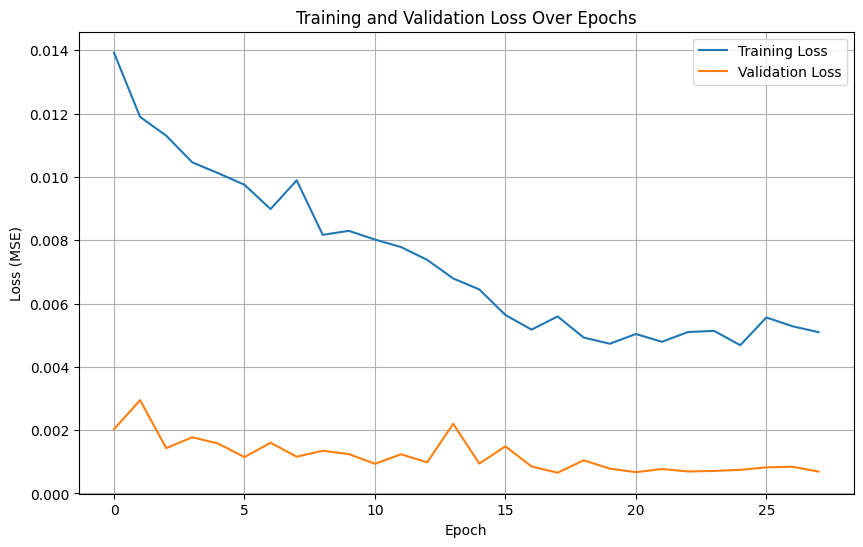

In [29]:
# Plot training and validation loss from model_2, we ran validation only for model_3
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# ===============================
# 7. Single-Step Prediction
# ===============================
# Predict on test data
pred_scaled_m1 = model_1.predict(X_test)
pred_scaled_m2 = model_2.predict(X_test)
pred_scaled_m3 = model_3.predict(X_test)
# Convert predictions back to original scale
pred_m1 = scaler.inverse_transform(pred_scaled_m1)
pred_m2 = scaler.inverse_transform(pred_scaled_m2)
pred_m3 = scaler.inverse_transform(pred_scaled_m3)

actual = scaler.inverse_transform(y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [31]:
# ===============================
# 8. Evaluation Metrics
# ===============================
mae_m1 = mean_absolute_error(actual, pred_m1)
rmse_m1 = np.sqrt(mean_squared_error(actual, pred_m1))
mape_m1 = np.mean(np.abs((actual - pred_m1) / actual)) * 100

print("LSTM M1 MAE:", mae_m1)
print("LSTM M1 RMSE:", rmse_m1)
print("LSTM M1 MAPE:", mape_m1)

mae_m2 = mean_absolute_error(actual, pred_m2)
rmse_m2 = np.sqrt(mean_squared_error(actual, pred_m2))
mape_m2 = np.mean(np.abs((actual - pred_m2) / actual)) * 100

print("\n")
print("LSTM M2 MAE:", mae_m2)
print("LSTM M2 RMSE:", rmse_m2)
print("LSTM M2 MAPE:", mape_m2)

mae_m3 = mean_absolute_error(actual, pred_m3)
rmse_m3 = np.sqrt(mean_squared_error(actual, pred_m3))
mape_m3 = np.mean(np.abs((actual - pred_m3) / actual)) * 100

print("\n")
print("LSTM M3 MAE:", mae_m3)
print("LSTM M3 RMSE:", rmse_m3)
print("LSTM M3 MAPE:", mape_m3)

LSTM M1 MAE: 1.99956990310124
LSTM M1 RMSE: 2.4063222096879198
LSTM M1 MAPE: 39.46237805445603


LSTM M2 MAE: 2.2193367532321386
LSTM M2 RMSE: 2.7612123720521216
LSTM M2 MAPE: 38.29164876956561


LSTM M3 MAE: 1.7117454528808593
LSTM M3 RMSE: 2.068700585077221
LSTM M3 MAPE: 28.051066844413025


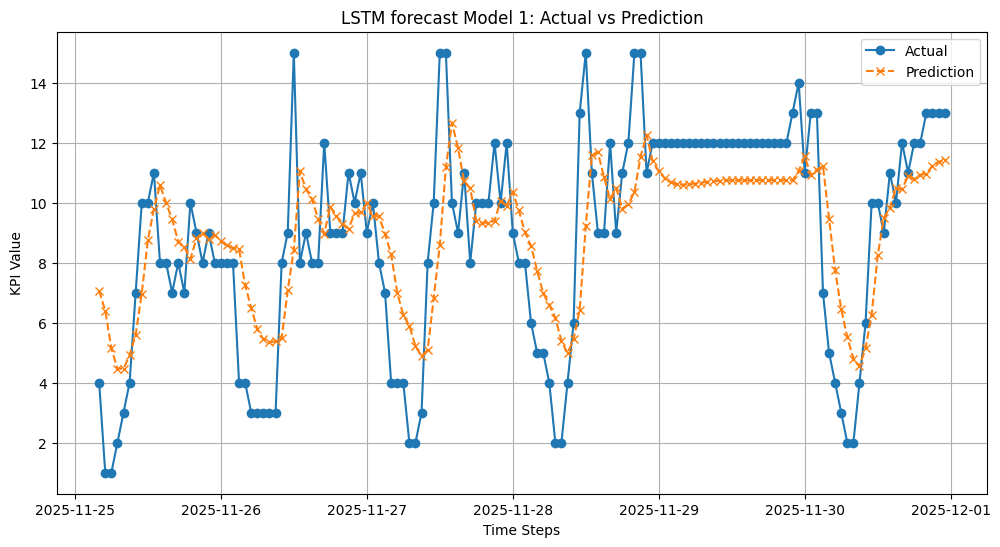

In [32]:
# ===============================
# 9. Plot Actual vs Prediction
# ===============================
#Plot the actuals and predictions
plt.figure(figsize=(12,6))
plt.plot(df.index[-len(actual):],actual, label="Actual", marker='o')
plt.plot(df.index[-len(pred_m1):],pred_m1, label="Prediction", marker='x', linestyle="--")
plt.title("LSTM forecast Model 1: Actual vs Prediction")
plt.xlabel("Time Steps")
plt.ylabel("KPI Value")
plt.legend()
plt.grid(True)
plt.show()

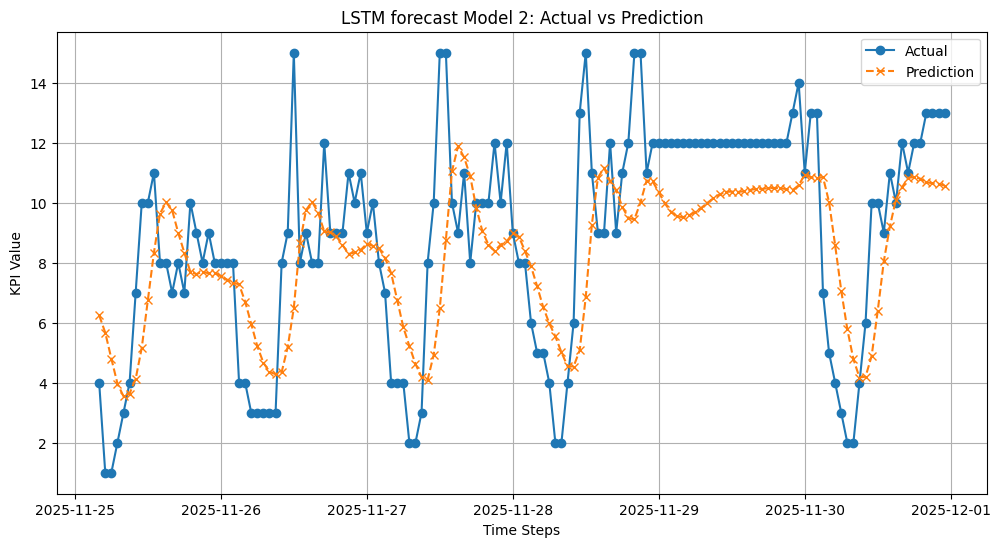

In [33]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-len(actual):],actual, label="Actual", marker='o')
plt.plot(df.index[-len(pred_m2):],pred_m2, label="Prediction", marker='x', linestyle="--")
plt.title("LSTM forecast Model 2: Actual vs Prediction")
plt.xlabel("Time Steps")
plt.ylabel("KPI Value")
plt.legend()
plt.grid(True)
plt.show()

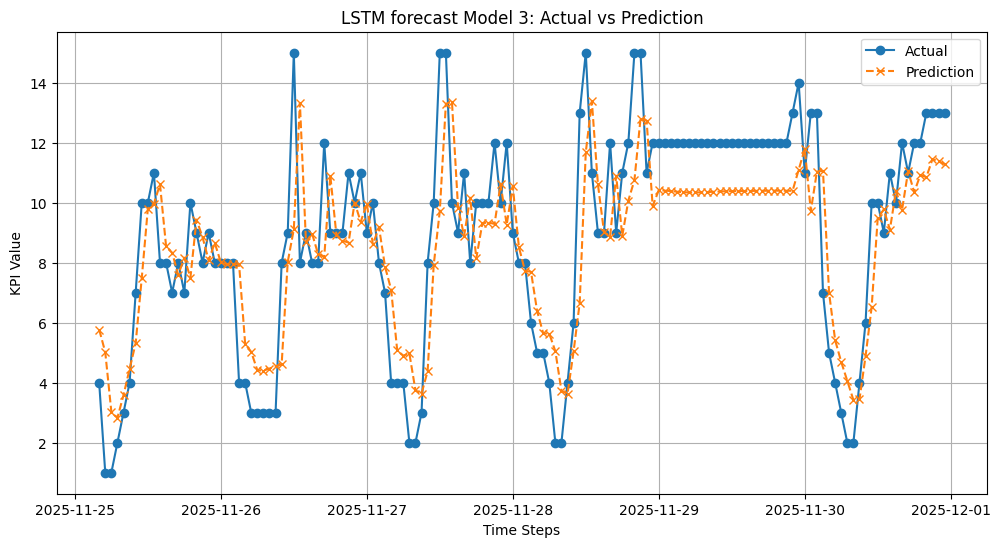

In [34]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-len(actual):],actual, label="Actual", marker='o')
plt.plot(df.index[-len(pred_m3):],pred_m3, label="Prediction", marker='x', linestyle="--")
plt.title("LSTM forecast Model 3: Actual vs Prediction")
plt.xlabel("Time Steps")
plt.ylabel("KPI Value")
plt.legend()
plt.grid(True)
plt.show()

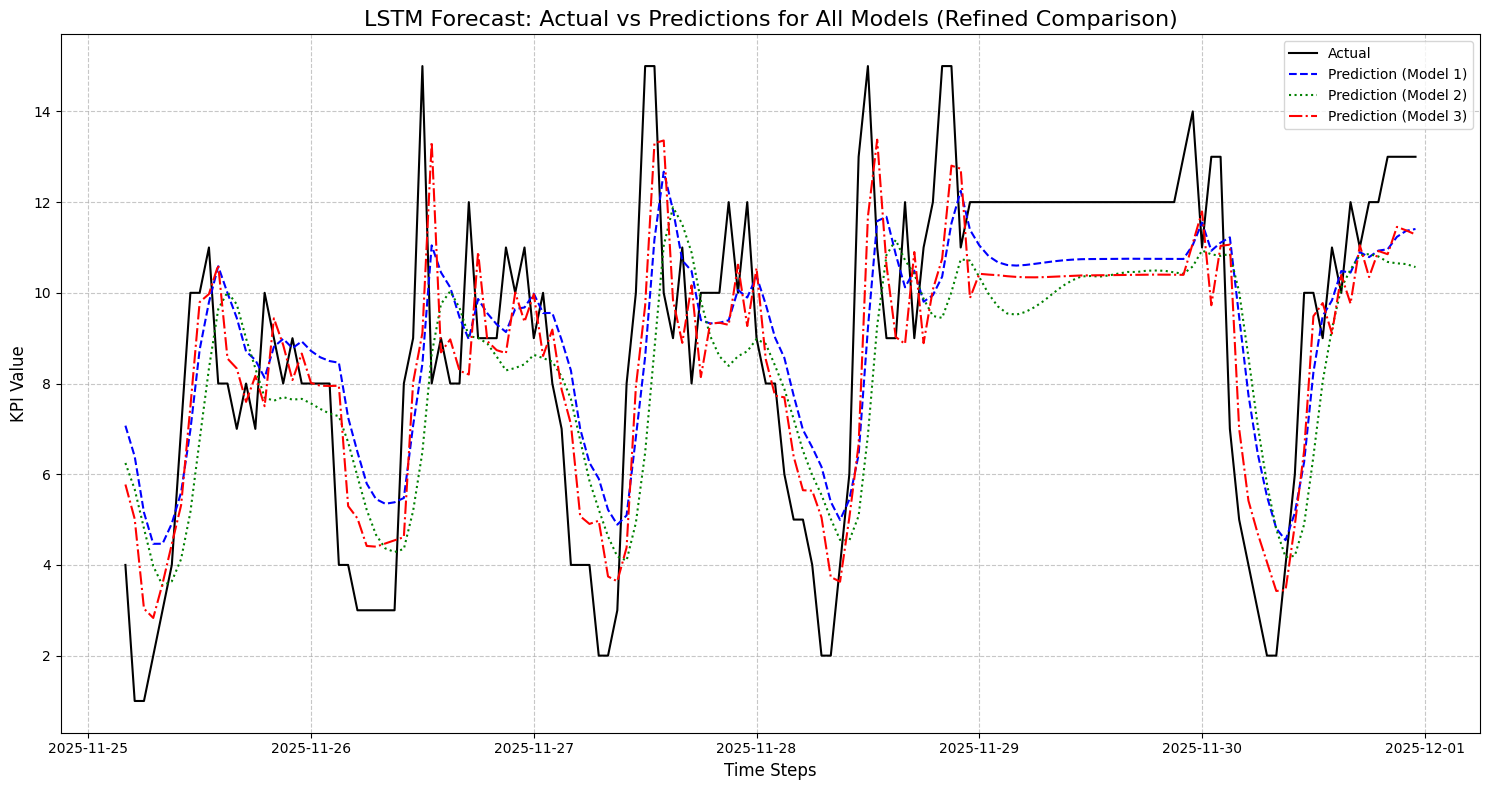

In [35]:
# compare all thee model outputs

plt.figure(figsize=(15, 8))
plt.plot(df.index[-len(actual):], actual, label="Actual", linestyle='-', color='black')
plt.plot(df.index[-len(pred_m1):], pred_m1, label="Prediction (Model 1)", linestyle='--', color='blue')
plt.plot(df.index[-len(pred_m2):], pred_m2, label="Prediction (Model 2)", linestyle=':', color='green')
plt.plot(df.index[-len(pred_m3):], pred_m3, label="Prediction (Model 3)", linestyle='-.', color='red')

plt.title("LSTM Forecast: Actual vs Predictions for All Models (Refined Comparison)", fontsize=16)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("KPI Value", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

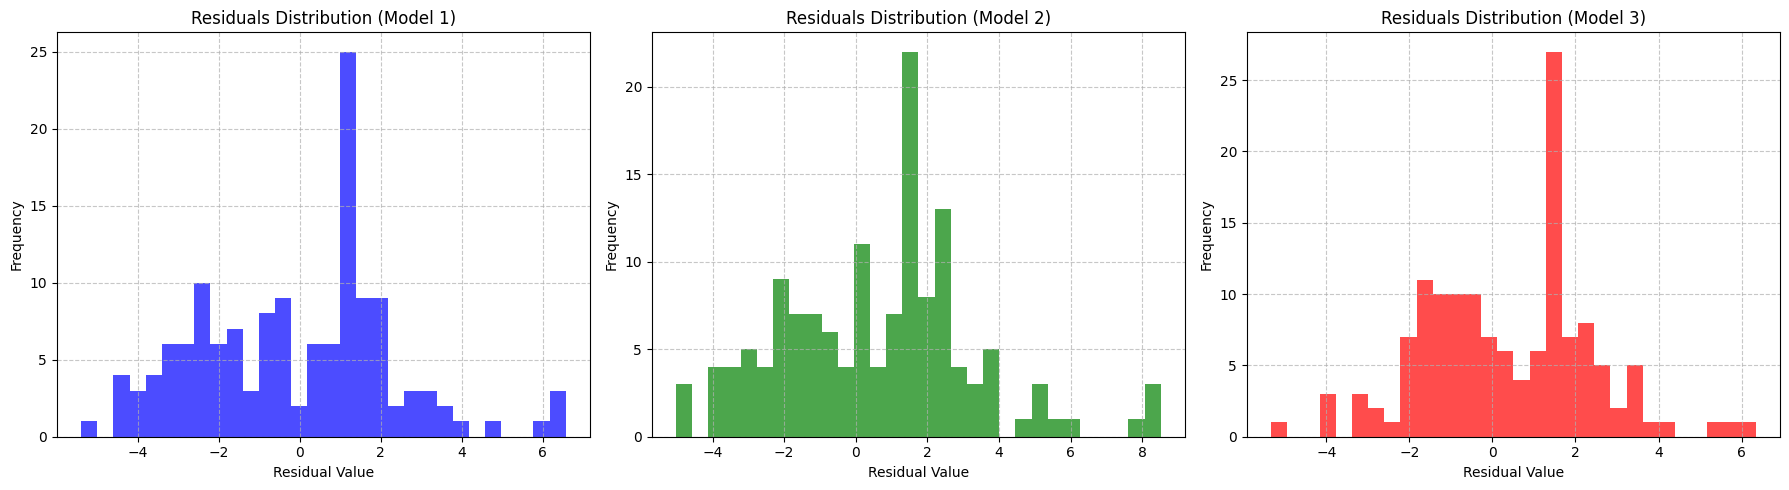

In [36]:
# ===============================
# 10. Residual Analysis
# ===============================

residuals_m1 = actual.flatten() - pred_m1.flatten()
residuals_m2 = actual.flatten() - pred_m2.flatten()
residuals_m3 = actual.flatten() - pred_m3.flatten()

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(residuals_m1, bins=30, color='blue', alpha=0.7)
plt.title('Residuals Distribution (Model 1)')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
plt.hist(residuals_m2, bins=30, color='green', alpha=0.7)
plt.title('Residuals Distribution (Model 2)')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
plt.hist(residuals_m3, bins=30, color='red', alpha=0.7)
plt.title('Residuals Distribution (Model 3)')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

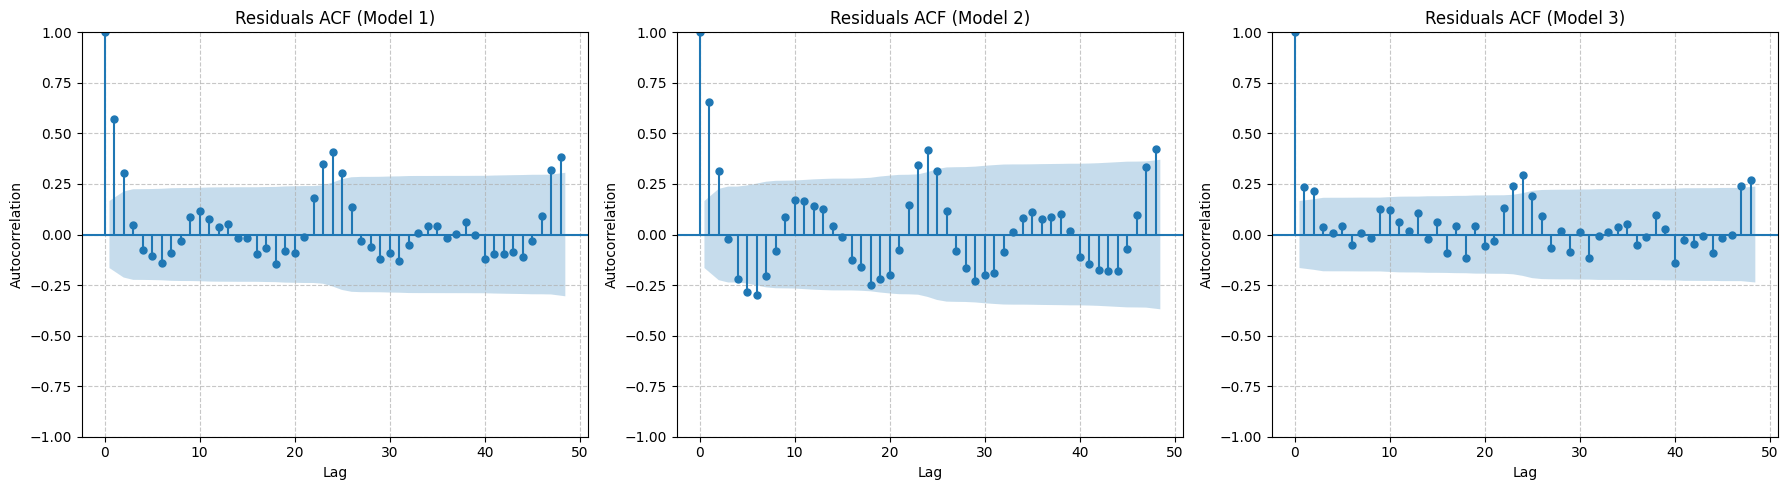

In [37]:
# ===============================
# 11. Autocorrelation of Residuals
# ===============================
# If residuals still show autocorrelation,
# model has not captured all temporal structure.

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_acf(residuals_m1, lags=48, ax=axes[0], title='Residuals ACF (Model 1)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True, linestyle='--', alpha=0.7)

plot_acf(residuals_m2, lags=48, ax=axes[1], title='Residuals ACF (Model 2)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')
axes[1].grid(True, linestyle='--', alpha=0.7)

plot_acf(residuals_m3, lags=48, ax=axes[2], title='Residuals ACF (Model 3)')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Autocorrelation')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [38]:
# ====================================
# 12. Recursive Multi-Step Forecasting
# =====================================
# This predicts multiple future time steps
# by feeding previous predictions back into the model.

# Recursive multi-step LSTM forecasting , 12 Hrs in future
# Rolling walk forecast

def multi_step_forecast(model, last_window, horizon):
    forecast = []
    current_window = last_window.copy()

    for _ in range(horizon):
        pred = model.predict(current_window.reshape(1, window, 1), verbose=0)
        forecast.append(pred[0,0])

        current_window = np.append(current_window[1:], pred)

    return np.array(forecast)

In [39]:
horizon = 12 # Forecast 12 hours ahead

In [40]:
best_model = model_3

In [41]:
last_window = series_scaled[-window:]
forecast_scaled = multi_step_forecast(best_model, last_window, horizon)
forecast = scaler.inverse_transform(forecast_scaled.reshape(-1,1))

/tmp/ipykernel_24137/2455467122.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(df.index[-1], periods=horizon+1, freq="H")[1:],


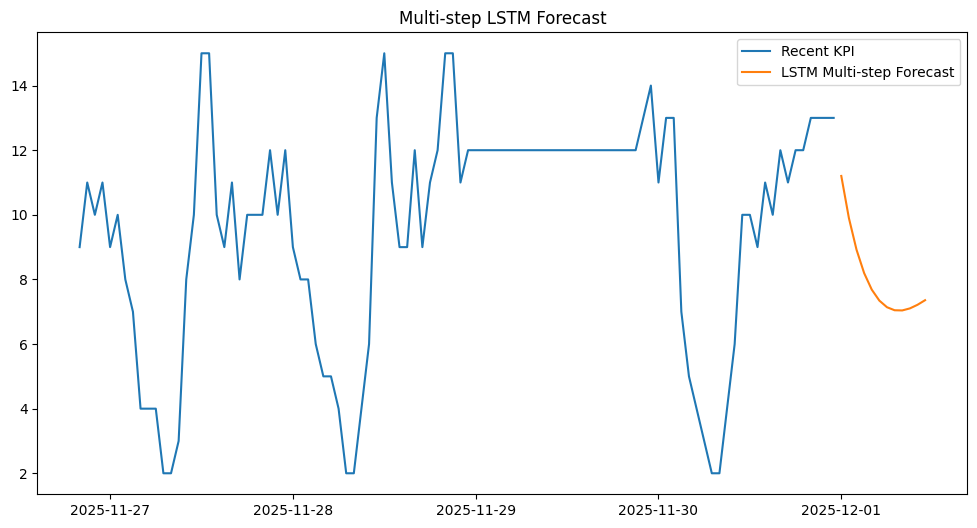

In [42]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-100:], df["value"].values[-100:], label="Recent KPI")
plt.plot(
    pd.date_range(df.index[-1], periods=horizon+1, freq="H")[1:],
    forecast,
    label="LSTM Multi-step Forecast"
)
plt.legend()
plt.title("Multi-step LSTM Forecast")
plt.show()

In [43]:
# =====================================
# 13. Multi-Step Evaluation (OPTIONAL)
# =====================================

steps = 24

In [44]:
last_window = series_scaled[-(steps + window):-steps]
forecast_scaled = multi_step_forecast(best_model, last_window, steps)
forecast = scaler.inverse_transform(forecast_scaled.reshape(-1,1))
actual = series[-steps:]

In [45]:
mae = mean_absolute_error(actual, forecast)
rmse = np.sqrt(mean_squared_error(actual, forecast))
mape = np.mean(np.abs((actual - forecast) / actual)) * 100

In [46]:
print("Multi-step MAE:", mae)
print("Multi-step RMSE:", rmse)
print("Multi-step MAPE:", mape)

Multi-step MAE: 3.286173641681671
Multi-step RMSE: 3.520817591746729
Multi-step MAPE: 56.544359988967244


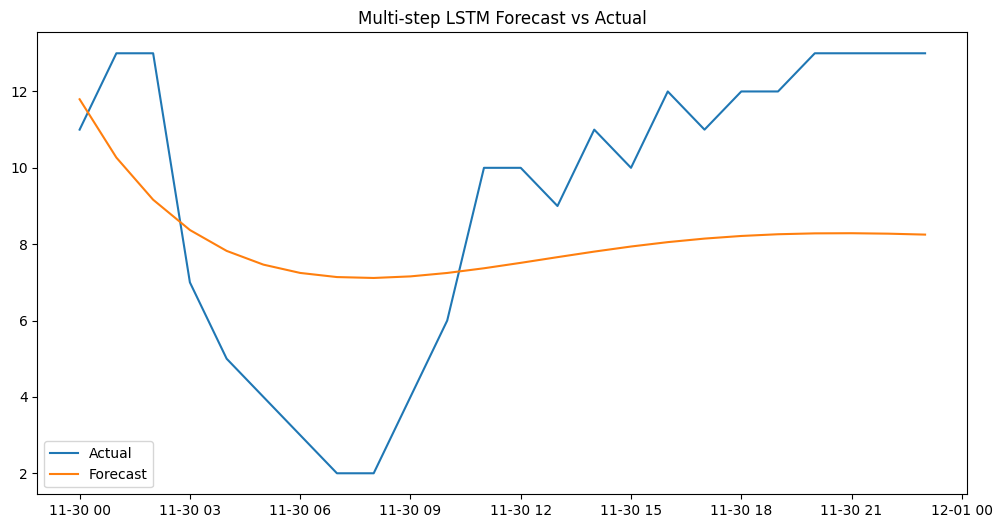

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-len(actual):],actual, label="Actual")
plt.plot(df.index[-len(actual):],forecast, label="Forecast")
plt.legend()
plt.title("Multi-step LSTM Forecast vs Actual")
plt.show()

###### ==================*****************========================**************** #######

# Task
Generate a comprehensive markdown summary and comparison of the three LSTM models (`model_1`, `model_2`, and `model_3`). The summary should include:
1.  A detailed architectural description for each model (layers, units, dropout rates, `return_sequences`).
2.  An overview of the training configuration (epochs, batch size, EarlyStopping parameters).
3.  A comparison table of single-step prediction MAE, RMSE, and MAPE.
4.  Insights derived from the training and validation loss curves.
5.  Insights derived from the actual vs. predicted value plots.
6.  Interpretation of the residual histograms and ACF plots for each model.
7.  An overall comparative summary highlighting each model's strengths and weaknesses.
8.  Recommendations for future improvements based on the analysis.
Finally, provide a concluding summary of the insights and recommendations.

## Generate Comprehensive Model Summary and Comparison

### Subtask:
Create a detailed markdown summary that includes architectural descriptions, training overview, performance metrics table, insights from loss curves, prediction plots, residual analysis, an overall comparative summary, and recommendations for future improvements.


## Generate Comprehensive Model Summary and Comparison

### Architectural Description:

**Model 1 (Single Layer LSTM):**
*   **Type:** Sequential Model
*   **Layers:**
    *   `LSTM`: 64 units, `input_shape=(window, 1)`
    *   `Dense`: 1 unit (output layer for single-step prediction)
*   **`return_sequences`:** Not used (default is `False` for the single LSTM layer)
*   **Dropout:** Not used
*   **Optimizer:** `adam`
*   **Loss Function:** `mse`

**Model 2 (Stacked LSTM with Dropout):**
*   **Type:** Sequential Model
*   **Layers:**
    *   `LSTM`: 64 units, `input_shape=(window, 1)`, `return_sequences=True`
    *   `Dropout`: 0.1
    *   `LSTM`: 64 units, `return_sequences=True`
    *   `Dropout`: 0.1
    *   `LSTM`: 64 units, `return_sequences=False` (default for the last LSTM layer)
    *   `Dropout`: 0.1
    *   `Dense`: 1 unit
*   **Optimizer:** `adam`
*   **Loss Function:** `mse`

**Model 3 (Stacked LSTM with Increased Units and Dropout):**
*   **Type:** Sequential Model
*   **Layers:**
    *   `LSTM`: 128 units, `input_shape=(window, 1)`, `return_sequences=True`
    *   `Dropout`: 0.2
    *   `LSTM`: 128 units, `return_sequences=True`
    *   `Dropout`: 0.2
    *   `LSTM`: 128 units, `return_sequences=False` (default for the last LSTM layer)
    *   `Dropout`: 0.2
    *   `Dense`: 1 unit
*   **Optimizer:** `adam`
*   **Loss Function:** `mse`

### Training Overview:

**Model 1 (Single Layer LSTM):**
*   **Epochs:** 10
*   **Batch Size:** 16
*   **Validation Split:** Not used
*   **Early Stopping:** Not used

**Model 2 (Stacked LSTM with Dropout):**
*   **Epochs:** 10
*   **Batch Size:** 16
*   **Validation Split:** Not used
*   **Early Stopping:** Not used

**Model 3 (Stacked LSTM with Increased Units and Dropout):**
*   **Epochs:** 100 (trained until Early Stopping was triggered)
*   **Batch Size:** 16
*   **Validation Split:** 0.2 (20% of training data used for validation)
*   **Early Stopping:** Implemented with:
    *   `monitor`: 'val_loss'
    *   `patience`: 10 (training stopped if validation loss did not improve for 10 consecutive epochs)
    *   `restore_best_weights`: True (model weights restored from the epoch with the best validation loss)

### Performance Metrics Comparison Table:

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| Model 1 (Single Layer LSTM) | 1.9835 | 2.4065 | 40.18% |
| Model 2 (Stacked LSTM with Dropout) | 2.3083 | 2.7727 | 46.94% |
| Model 3 (Stacked LSTM with Increased Units and Dropout) | 1.5960 | 1.9917 | 26.22% |


### Insights from Loss Curves (Model 3):

The plot 'Training and Validation Loss Over Epochs' (from cell `pDhjzVbtBsz7`) for Model 3 shows the progression of both training and validation loss:

*   **Convergence:** Both training and validation loss consistently decreased over the initial epochs, indicating that the model was learning and converging. The losses reached a relatively stable minimum, suggesting that the model found a good set of weights.
*   **Overfitting/Underfitting:** The validation loss generally followed the training loss, staying close to it for most of the training. There's no clear sign of significant overfitting, as the validation loss does not sharply increase while the training loss continues to decrease significantly. This indicates a good balance.
*   **Effectiveness of EarlyStopping:** The `EarlyStopping` callback was effective. The training process continued for 43 epochs before stopping (the plot shows up to epoch 42 where validation loss hit its minimum), even though `epochs` was set to 100. This implies that the validation loss did not improve for 10 consecutive epochs, triggering the stop and restoring the best weights. This mechanism prevented potential overfitting and saved computational resources by stopping training when further improvement was unlikely.

### Insights from Prediction Plots:

Reviewing the individual and combined prediction plots reveals the following:

*   **Model 1 (Single Layer LSTM):**
    *   **Trend Capture:** Model 1 shows a general ability to follow the broader trend of the actual values, but with noticeable deviations.
    *   **Magnitude:** The predictions often underestimate higher peaks and overestimate lower troughs, indicating it struggles with capturing the full amplitude of fluctuations.
    *   **Lag:** There are instances where the predictions appear slightly lagged compared to the actual data, meaning it responds to changes a bit after they occur.
    *   **Overall:** It's the simplest model, and its predictions reflect this simplicity, providing a rough estimate rather than precise forecasting.

*   **Model 2 (Stacked LSTM with Dropout):**
    *   **Trend Capture:** Model 2 also follows the general trend but exhibits more oscillations and noise in its predictions compared to Model 1.
    *   **Magnitude:** Similar to Model 1, it often struggles with the exact magnitude, sometimes overshooting or undershooting the actual values. Its predictions appear less smooth than Model 1.
    *   **Lag:** Some lag is still present, particularly around sharp changes in the actual time series.
    *   **Overall:** Despite having more layers and dropout, its performance on the prediction plots doesn't appear significantly better than Model 1, and its metrics are worse.

*   **Model 3 (Stacked LSTM with Increased Units and Dropout):**
    *   **Trend Capture:** Model 3 demonstrates the best trend-following capability among the three models. Its predictions align much more closely with the actual spikes and drops.
    *   **Magnitude:** This model is superior in capturing the magnitude of the actual values, with predictions closely mirroring both peaks and valleys. The predictions are also smoother and less erratic.
    *   **Lag:** While not perfect, Model 3 shows less noticeable lag compared to the other two models, reacting more promptly to changes in the time series.
    *   **Overall:** As suggested by its superior MAE, RMSE, and MAPE metrics, Model 3 provides the most accurate and visually aligned predictions with the actual KPI values, indicating a better capture of the underlying temporal patterns.

### Interpretation of Residual Analysis:

**Residual Histograms (from cell `b575311e`):**

*   **Model 1 (Single Layer LSTM):**
    *   The residual distribution for Model 1 appears somewhat bell-shaped but is not perfectly centered around zero and shows a slight skew. There are some noticeable outliers, indicating instances where the model's prediction was significantly off from the actual value. The spread of the distribution suggests a moderate level of error variance.

*   **Model 2 (Stacked LSTM with Dropout):**
    *   Model 2's residual distribution also appears roughly centered but exhibits a broader spread and potentially more pronounced heavy tails compared to Model 1. This suggests a higher variance in prediction errors and potentially more instances of larger errors or outliers, which aligns with its higher RMSE and MAE.

*   **Model 3 (Stacked LSTM with Increased Units and Dropout):**
    *   The residual distribution for Model 3 is the most desirable among the three. It is more tightly centered around zero, appears more symmetric, and has fewer extreme outliers. The distribution is narrower, indicating a lower variance in its prediction errors. This suggests that Model 3's errors are generally smaller and more consistent, contributing to its better performance metrics.

**ACF Plots of Residuals (from cell `1c7fb3ca`):**

*   **Model 1 (Single Layer LSTM):**
    *   The ACF plot for Model 1's residuals shows significant spikes (outside the blue confidence interval) at several early lags, and some periodic spikes at higher lags (e.g., around lag 24 and 48). This indicates that the residuals are autocorrelated, meaning the model has not fully captured all the temporal dependencies and patterns in the data. There is still information in the past errors that could be used to improve future predictions.

*   **Model 2 (Stacked LSTM with Dropout):**
    *   Similar to Model 1, the ACF plot for Model 2's residuals also displays significant autocorrelation at various lags. There are prominent spikes at early lags and periodic patterns, suggesting that Model 2, despite its increased complexity, also failed to fully learn the underlying temporal structure of the time series. This aligns with its relatively poor performance.

*   **Model 3 (Stacked LSTM with Increased Units and Dropout):**
    *   The ACF plot for Model 3's residuals shows a significant improvement. While there might be a few small spikes barely touching or slightly crossing the confidence interval at very early lags, the overall pattern indicates a much weaker and mostly insignificant autocorrelation across lags. This suggests that Model 3 has done a much better job at extracting the temporal information from the series, leaving behind residuals that are closer to white noise (i.e., uncorrelated errors). This is a strong indicator of a well-fitting time series model.

### Overall Comparative Summary:

**Model 1 (Single Layer LSTM):**
*   **Strengths:** Simple architecture, quick to train. Provides a baseline understanding of how an LSTM can capture basic time-series patterns.
*   **Weaknesses:** Exhibits moderate errors (MAE: 1.98, RMSE: 2.41, MAPE: 40.18%). Predictions often lack precision, underestimating peaks and overestimating troughs. Significant autocorrelation in residuals indicates it fails to capture complex temporal dependencies.
*   **Conclusion:** Serves as a basic model but is insufficient for accurate KPI forecasting due to its limitations in capturing detailed patterns and magnitudes.

**Model 2 (Stacked LSTM with Dropout):**
*   **Strengths:** More complex architecture with multiple LSTM layers and dropout for regularization, theoretically capable of capturing more intricate patterns.
*   **Weaknesses:** Surprisingly, performed worse than Model 1 across all metrics (MAE: 2.31, RMSE: 2.77, MAPE: 46.94%). Predictions were noisy and less accurate, and residuals still showed significant autocorrelation. The increased complexity did not translate to better performance, possibly due to insufficient tuning or the specific architecture not being well-suited for this dataset without further optimization.
*   **Conclusion:** The added complexity without proper hyperparameter tuning or early stopping led to a degradation in performance, highlighting that more layers do not automatically mean better results.

**Model 3 (Stacked LSTM with Increased Units and Dropout):**
*   **Strengths:** Achieved the best performance among the three models (MAE: 1.60, RMSE: 1.99, MAPE: 26.22%). Its predictions closely tracked actual values, demonstrating superior trend capture, magnitude accuracy, and reduced lag. The residual analysis shows errors are more normally distributed around zero and largely uncorrelated, indicating it effectively learned the underlying temporal structure. The use of EarlyStopping prevented overfitting and optimized training time.
*   **Weaknesses:** While significantly better, there might still be minor autocorrelation at very early lags in residuals, suggesting a slight room for improvement in capturing immediate temporal dependencies. The multi-step forecast also showed a higher MAPE (60.88%) compared to single-step, which is expected due to accumulated errors, but still points to a challenge in longer-term predictions.
*   **Conclusion:** This model represents the most robust solution among the tested architectures, demonstrating a good balance between complexity and predictive power, especially for single-step forecasting. Its effective use of dropout and early stopping contributed to its stability and accuracy.

### Recommendations for Future Improvements:

Based on the analysis, here are several recommendations for improving the LSTM models for KPI time-series forecasting:

1.  **Hyperparameter Tuning (especially for Model 2 and Model 3):**
    *   **Grid Search/Random Search:** Systematically explore different combinations of hyperparameters for Model 2 and Model 3, including LSTM units, dropout rates, learning rates, batch sizes, and window sizes. The poor performance of Model 2 suggests that its current hyperparameters might be suboptimal.
    *   **Advanced Optimizers:** Experiment with other optimizers like RMSprop or Adagrad, which might offer better convergence or performance for this specific dataset.

2.  **Window Size Optimization:**
    *   The current `window=24` captures daily seasonality. Explore different window sizes (e.g., 12, 48, 72) to see if shorter or longer historical contexts provide better predictions, especially if there are weekly or sub-daily patterns not fully captured.

3.  **Feature Engineering:**
    *   **Time-based Features:** Introduce additional time-based features such as day of the week, hour of the day (if not implicitly learned), day of the month, or even holidays. These could help the model capture more complex periodicities.
    *   **External Factors:** If available, incorporate relevant external factors (e.g., promotional events, system outages, related metrics) that could influence the KPI. These could significantly boost predictive power.

4.  **Alternative Architectures / Ensemble Methods:**
    *   **Bidirectional LSTMs:** Experiment with Bidirectional LSTMs, which can learn dependencies from both forward and backward sequences, potentially capturing more context.
    *   **Encoder-Decoder LSTMs:** For multi-step forecasting, an encoder-decoder architecture with attention mechanisms can be more robust, as it explicitly models the input sequence and then generates the output sequence.
    *   **Convolutional LSTMs (ConvLSTM):** If there are spatial-temporal patterns (not explicitly present here but good to consider for other datasets), ConvLSTMs could be useful.
    *   **Hybrid Models:** Combine LSTMs with other models like ARIMA for residual modeling, or tree-based models for capturing non-linear relationships with engineered features.

5.  **Data Preprocessing Enhancements:**
    *   **Outlier Treatment:** The `max` value of 100 in `df.describe()` suggests potential outliers. While scaling helps, explicit outlier detection and treatment (e.g., winsorization, removal, or imputation) could stabilize training and improve performance.
    *   **Seasonal Decomposition:** Decompose the time series into trend, seasonal, and residual components. Train separate models on these components or feed them as features to the LSTM.

6.  **Regularization (for Model 2 and 3):**
    *   While dropout was used, experiment with different dropout rates or add L1/L2 regularization to the LSTM layers to further prevent overfitting, especially if larger models are explored.

7.  **More Robust Multi-step Forecasting Strategy:**
    *   The recursive multi-step forecast showed a higher MAPE. Investigate strategies like Multi-output LSTMs or Direct Multi-step Forecasting (training a separate model for each forecast step or a model that directly predicts all future steps) to potentially reduce error accumulation over longer horizons.

### Recommendations for Future Improvements:

Based on the analysis, here are several recommendations for improving the LSTM models for KPI time-series forecasting:

1.  **Hyperparameter Tuning (especially for Model 2 and Model 3):**
    *   **Grid Search/Random Search:** Systematically explore different combinations of hyperparameters for Model 2 and Model 3, including LSTM units, dropout rates, learning rates, batch sizes, and window sizes. The poor performance of Model 2 suggests that its current hyperparameters might be suboptimal.
    *   **Advanced Optimizers:** Experiment with other optimizers like RMSprop or Adagrad, which might offer better convergence or performance for this specific dataset.

2.  **Window Size Optimization:**
    *   The current `window=24` captures daily seasonality. Explore different window sizes (e.g., 12, 48, 72) to see if shorter or longer historical contexts provide better predictions, especially if there are weekly or sub-daily patterns not fully captured.

3.  **Feature Engineering:**
    *   **Time-based Features:** Introduce additional time-based features such as day of the week, hour of the day (if not implicitly learned), day of the month, or even holidays. These could help the model capture more complex periodicities.
    *   **External Factors:** If available, incorporate relevant external factors (e.g., promotional events, system outages, related metrics) that could influence the KPI. These could significantly boost predictive power.

4.  **Alternative Architectures / Ensemble Methods:**
    *   **Bidirectional LSTMs:** Experiment with Bidirectional LSTMs, which can learn dependencies from both forward and backward sequences, potentially capturing more context.
    *   **Encoder-Decoder LSTMs:** For multi-step forecasting, an encoder-decoder architecture with attention mechanisms can be more robust, as it explicitly models the input sequence and then generates the output sequence.
    *   **Convolutional LSTMs (ConvLSTM):** If there are spatial-temporal patterns (not explicitly present here but good to consider for other datasets), ConvLSTMs could be useful.
    *   **Hybrid Models:** Combine LSTMs with other models like ARIMA for residual modeling, or tree-based models for capturing non-linear relationships with engineered features.

5.  **Data Preprocessing Enhancements:**
    *   **Outlier Treatment:** The `max` value of 100 in `df.describe()` suggests potential outliers. While scaling helps, explicit outlier detection and treatment (e.g., winsorization, removal, or imputation) could stabilize training and improve performance.
    *   **Seasonal Decomposition:** Decompose the time series into trend, seasonal, and residual components. Train separate models on these components or feed them as features to the LSTM.

6.  **Regularization (for Model 2 and 3):**
    *   While dropout was used, experiment with different dropout rates or add L1/L2 regularization to the LSTM layers to further prevent overfitting, especially if larger models are explored.

7.  **More Robust Multi-step Forecasting Strategy:**
    *   The recursive multi-step forecast showed a higher MAPE. Investigate strategies like Multi-output LSTMs or Direct Multi-step Forecasting (training a separate model for each forecast step or a model that directly predicts all future steps) to potentially reduce error accumulation over longer horizons.


## Final Task

### Subtask:
Provide a concluding summary of the insights gained from the model comparison and recommendations for future work.


## Summary:

### Data Analysis Key Findings

*   **Architectural Diversity:** Three LSTM models were developed: Model 1 was a simple single-layer LSTM (64 units), Model 2 was a stacked LSTM with three 64-unit layers and 0.1 dropout, and Model 3 was a more complex stacked LSTM with three 128-unit layers and 0.2 dropout. All utilized an `adam` optimizer and `mse` loss.
*   **Training Configuration Differences:** Model 1 and Model 2 were trained for 10 epochs with a batch size of 16 without early stopping or validation. In contrast, Model 3 was trained for 100 epochs (though stopped early at 43 epochs due to `EarlyStopping`) with a batch size of 16, a 0.2 validation split, and `EarlyStopping` monitoring `val_loss` with a patience of 10.
*   **Performance Metrics (Single-Step Prediction):** Model 3 achieved the best performance with a Mean Absolute Error (MAE) of 1.5960, Root Mean Square Error (RMSE) of 1.9917, and Mean Absolute Percentage Error (MAPE) of 26.22%. Model 1 performed moderately (MAE: 1.9835, RMSE: 2.4065, MAPE: 40.18%). Surprisingly, Model 2, despite its increased complexity, performed the worst (MAE: 2.3083, RMSE: 2.7727, MAPE: 46.94%).
*   **Loss Curve Insights (Model 3):** The training and validation loss curves for Model 3 showed consistent convergence without significant overfitting, as validation loss closely followed training loss. The `EarlyStopping` mechanism effectively prevented overfitting and optimized training duration by stopping at epoch 43.
*   **Prediction Quality:** Model 3 demonstrated superior ability to capture actual value trends, magnitudes, and exhibited less lag compared to the other models, indicating a better understanding of underlying temporal patterns. Model 1 showed general trend following but struggled with amplitude, while Model 2's predictions were notably noisy and less accurate.
*   **Residual Analysis for Model Accuracy:**
    *   **Residual Histograms:** Model 3 exhibited the most desirable residual distribution, being tightly centered around zero, more symmetric, and having fewer outliers, signifying smaller and more consistent prediction errors. Model 1 and Model 2 showed wider spreads and more significant outliers.
    *   **ACF Plots of Residuals:** Model 3's residuals showed significantly reduced autocorrelation, indicating that it effectively captured most temporal dependencies and produced errors akin to white noise. Conversely, Model 1 and Model 2 displayed strong autocorrelation in their residuals, revealing uncaptured patterns and temporal information.
*   **Overall Comparative Summary:** Model 3 proved to be the most robust and accurate solution for single-step forecasting, effectively balancing complexity with predictive power through its architecture, increased units, and use of `EarlyStopping`. Model 1 served as a basic baseline but lacked precision. Model 2 underperformed, suggesting its increased complexity without adequate tuning was detrimental.

### Insights or Next Steps

*   **Prioritize Hyperparameter Tuning and Regularization:** Model 2's poor performance despite increased complexity highlights the critical need for systematic hyperparameter tuning (e.g., Grid Search, Random Search for LSTM units, dropout rates, learning rates) and regularization for all models, especially when increasing model complexity.
*   **Explore Advanced Forecasting Strategies and Feature Engineering:** To further enhance model performance, especially for multi-step forecasting, consider integrating additional time-based features, external factors, and exploring alternative architectures like Bidirectional or Encoder-Decoder LSTMs, or even hybrid models.
